# Driver-Based Financial Forecasting System

## Project Objective

I built this project as an end-to-end financial forecasting system using daily store-level sales data.

The goal is not only to predict revenue. The goal is to understand which business drivers move sales and then use the model for planning decisions.

I treated this like a finance science problem:

1. **Forecast accuracy:** Can I predict future daily sales better than simple planning rules?
2. **Leakage control:** Am I only using information that would be available at forecast time?
3. **Business interpretation:** Which drivers matter most to the model?
4. **Scenario planning:** How does forecasted revenue change under promotion and demand-shock assumptions?
5. **Production readiness:** How would this be monitored, retrained, and used safely in a real finance workflow?

## Dataset

I used the Rossmann daily store sales dataset, which includes store-level sales, promotions, holidays, store metadata, and competition information.




## 0. Project Setup


In [42]:
# Google Colab setup
!pip install -q xgboost shap seaborn

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

import shap
import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.rcParams["figure.figsize"] = (14, 6)
sns.set_theme(style="whitegrid")



## 1. Data Loading

The sales table contains daily store-level outcomes.  
The store table contains business context such as store format, assortment, competition distance, and long-running promotion information.

In [2]:
train_url = "https://raw.githubusercontent.com/dmi3kno/Kaggle-Rossmann/master/train.csv"
store_url = "https://raw.githubusercontent.com/dmi3kno/Kaggle-Rossmann/master/store.csv"

train = pd.read_csv(train_url, parse_dates=["Date"], low_memory=False)
store = pd.read_csv(store_url, low_memory=False)

print("Train shape:", train.shape)
print("Store shape:", store.shape)

display(train.head())
display(store.head())

Train shape: (1017209, 9)
Store shape: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,"1,270.000",9.000,"2,008.000",0,NaN,NaN,NaN
1,2,a,a,570.000,11.000,"2,007.000",1,13.000,"2,010.000","Jan,Apr,Jul,Oct"
2,3,a,a,"14,130.000",12.000,"2,006.000",1,14.000,"2,011.000","Jan,Apr,Jul,Oct"
3,4,c,c,620.000,9.000,"2,009.000",0,NaN,NaN,NaN
4,5,a,a,"29,910.000",4.000,"2,015.000",0,NaN,NaN,NaN


### Merge sales and store context

I merge on `Store` because daily sales need store-level drivers attached before modeling.

In [3]:
df = train.merge(store, on="Store", how="left")
df = df.sort_values(["Date", "Store"]).reset_index(drop=True)

print("Merged shape:", df.shape)
display(df.head())

Merged shape: (1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2,2013-01-01,0,0,0,0,a,1,c,a,"1,270.000",9.000,"2,008.000",0,NaN,NaN,NaN
1,2,2,2013-01-01,0,0,0,0,a,1,a,a,570.000,11.000,"2,007.000",1,13.000,"2,010.000","Jan,Apr,Jul,Oct"
2,3,2,2013-01-01,0,0,0,0,a,1,a,a,"14,130.000",12.000,"2,006.000",1,14.000,"2,011.000","Jan,Apr,Jul,Oct"
3,4,2,2013-01-01,0,0,0,0,a,1,c,c,620.000,9.000,"2,009.000",0,NaN,NaN,NaN
4,5,2,2013-01-01,0,0,0,0,a,1,a,a,"29,910.000",4.000,"2,015.000",0,NaN,NaN,NaN


## 2. Data Quality Checks

Before modeling, I want to understand the time coverage, missing values, store count, and zero-sales rows.  
This step matters because forecasting projects can look accurate for the wrong reason if closed stores, missing values, or leakage are not handled carefully.

In [4]:
print("Dataset shape:", df.shape)
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Unique stores:", df["Store"].nunique())

closed_rows = (df["Open"] == 0).sum()
zero_sales_rows = (df["Sales"] == 0).sum()

print("Closed-store rows:", f"{closed_rows:,}", f"({closed_rows / len(df):.2%})")
print("Zero-sales rows:", f"{zero_sales_rows:,}", f"({zero_sales_rows / len(df):.2%})")

missing = df.isnull().sum().sort_values(ascending=False).to_frame("missing_count")
missing["missing_pct"] = missing["missing_count"] / len(df) * 100

display(missing[missing["missing_count"] > 0])

print("Data quality note:")
print("Closed stores are valid business observations, but I inspect open stores separately during EDA so zero sales do not hide true demand patterns.")

Dataset shape: (1017209, 18)
Date range: 2013-01-01 to 2015-07-31
Unique stores: 1115
Closed-store rows: 172,817 (16.99%)
Zero-sales rows: 172,871 (16.99%)


,missing_count,missing_pct
Promo2SinceWeek,508031,49.944
PromoInterval,508031,49.944
Promo2SinceYear,508031,49.944
CompetitionOpenSinceYear,323348,31.788
CompetitionOpenSinceMonth,323348,31.788
CompetitionDistance,2642,0.260


Data quality note:
Closed stores are valid business observations, but I inspect open stores separately during EDA so zero sales do not hide true demand patterns.


## 3. Exploratory Driver Analysis

In this section, I look for patterns that should become model features.  
I am not trying to prove causality here. I am trying to identify useful forecasting signals.

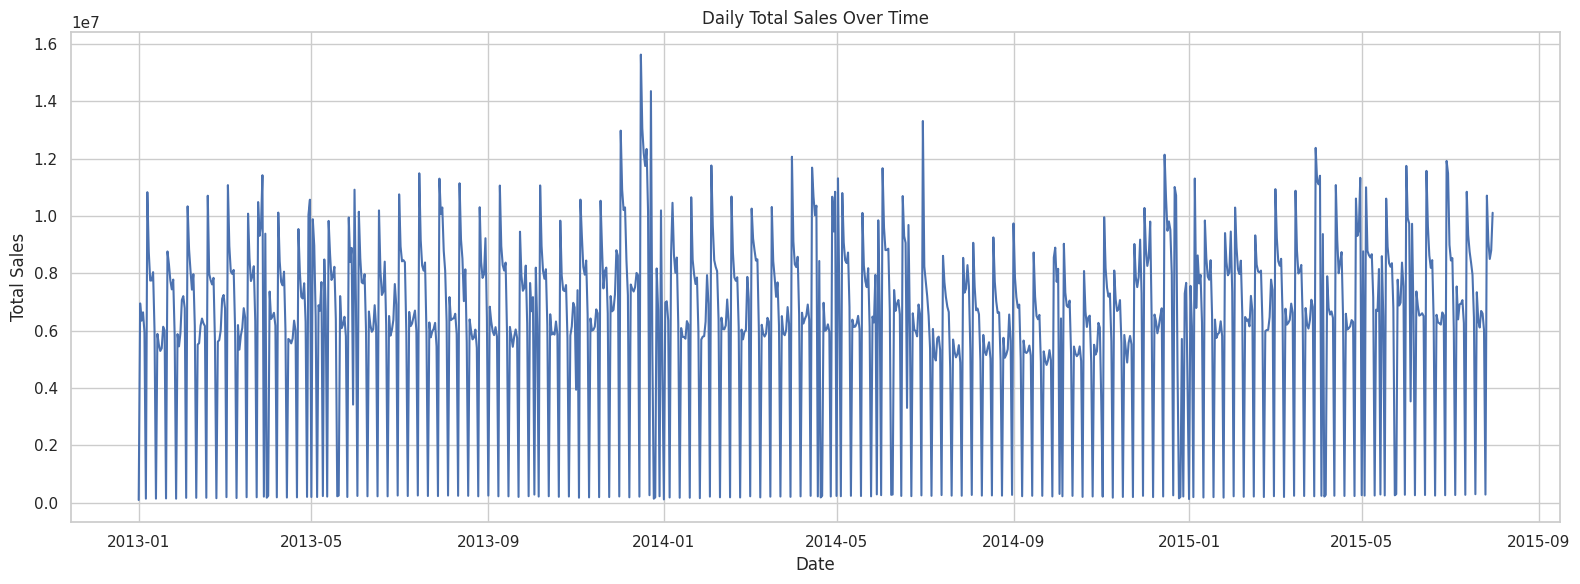

My read:
- Sales move in visible weekly and seasonal patterns.
- Large drops often come from store closures or holidays.
- This supports using calendar, holiday, open/closed, and recent-demand features.


In [5]:
daily_sales = df.groupby("Date", as_index=False)["Sales"].sum()

plt.figure(figsize=(16, 6))
plt.plot(daily_sales["Date"], daily_sales["Sales"])
plt.title("Daily Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

print("My read:")
print("- Sales move in visible weekly and seasonal patterns.")
print("- Large drops often come from store closures or holidays.")
print("- This supports using calendar, holiday, open/closed, and recent-demand features.")

In [6]:
open_df = df[df["Open"] == 1].copy()
closed_df = df[df["Open"] == 0].copy()

print("Open-store rows:", f"{len(open_df):,}")
print("Closed-store rows:", f"{len(closed_df):,}")

print("I use open_df for demand-pattern EDA, but I keep Open in the modeling dataset because closures are part of real forecasting.")

Open-store rows: 844,392
Closed-store rows: 172,817
I use open_df for demand-pattern EDA, but I keep Open in the modeling dataset because closures are part of real forecasting.


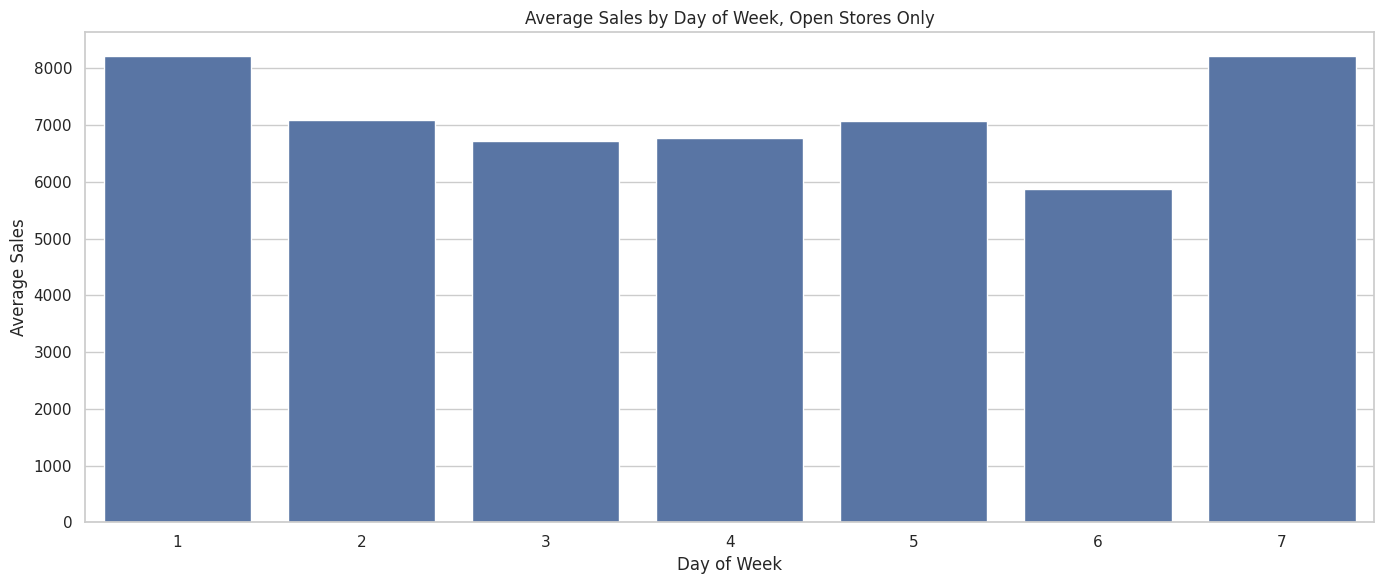

,DayOfWeek,Sales
0,1,"8,216.073"
1,2,"7,088.114"
2,3,"6,728.123"
3,4,"6,767.310"
4,5,"7,072.677"
5,6,"5,874.840"
6,7,"8,224.724"


My decision: I keep day-of-week as a core feature because Day 7 has the highest average sales and sales clearly follow weekly operating patterns.


In [7]:
dow_sales = open_df.groupby("DayOfWeek", as_index=False)["Sales"].mean().sort_values("DayOfWeek")

sns.barplot(data=dow_sales, x="DayOfWeek", y="Sales")
plt.title("Average Sales by Day of Week, Open Stores Only")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

best_day = dow_sales.loc[dow_sales["Sales"].idxmax(), "DayOfWeek"]
display(dow_sales)

print(f"My decision: I keep day-of-week as a core feature because Day {best_day} has the highest average sales and sales clearly follow weekly operating patterns.")

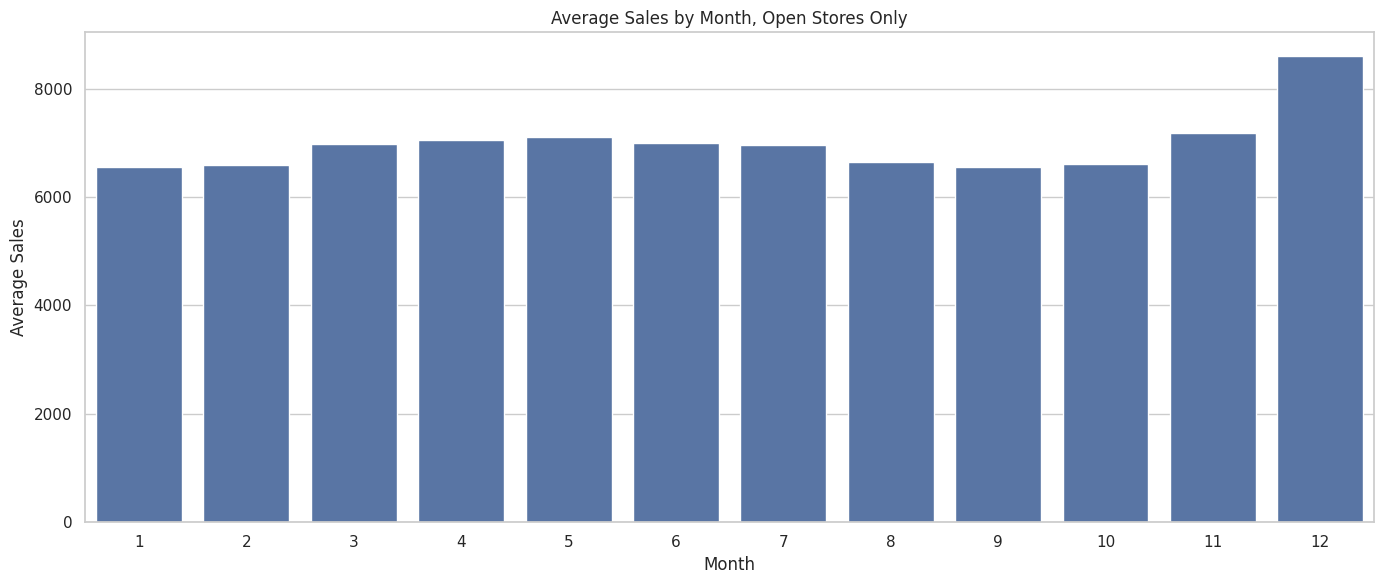

,Month,Sales
0,1,"6,563.690"
1,2,"6,589.166"
2,3,"6,976.412"
3,4,"7,046.228"
4,5,"7,106.453"
5,6,"7,000.978"
6,7,"6,952.682"
7,8,"6,648.985"
8,9,"6,546.343"
9,10,"6,602.843"


My decision: I keep month and week features because Month 12 has the highest average sales and seasonality matters for planning.


In [8]:
open_df["Month"] = open_df["Date"].dt.month

month_sales = open_df.groupby("Month", as_index=False)["Sales"].mean().sort_values("Month")

sns.barplot(data=month_sales, x="Month", y="Sales")
plt.title("Average Sales by Month, Open Stores Only")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

best_month = month_sales.loc[month_sales["Sales"].idxmax(), "Month"]
display(month_sales)

print(f"My decision: I keep month and week features because Month {best_month} has the highest average sales and seasonality matters for planning.")

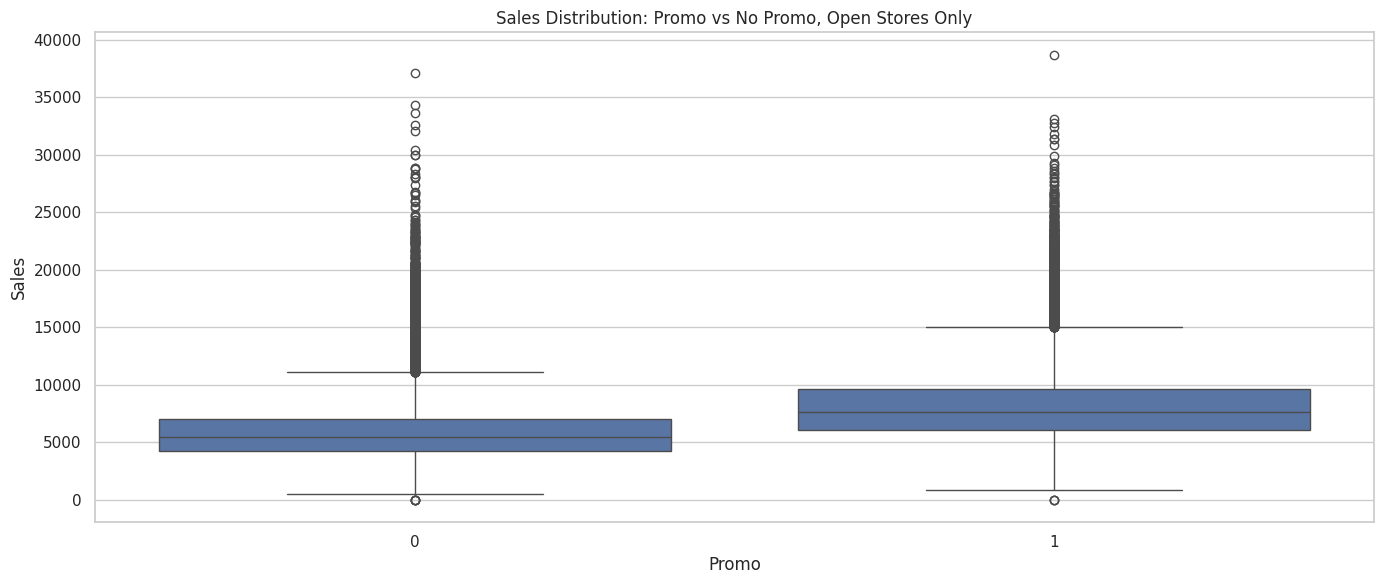

Average sales without promo: $5,929
Average sales with promo:    $8,228
Observed promo lift:         38.8%
Interpretation: I use promotion as a forecasting driver, but this observed lift is correlation, not causal proof.


In [9]:
promo_sample = open_df.sample(min(100_000, len(open_df)), random_state=RANDOM_STATE)

sns.boxplot(data=promo_sample, x="Promo", y="Sales")
plt.title("Sales Distribution: Promo vs No Promo, Open Stores Only")
plt.xlabel("Promo")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

promo_avg = open_df.groupby("Promo")["Sales"].mean()
promo_lift = (promo_avg.loc[1] - promo_avg.loc[0]) / promo_avg.loc[0] * 100

print(f"Average sales without promo: ${promo_avg.loc[0]:,.0f}")
print(f"Average sales with promo:    ${promo_avg.loc[1]:,.0f}")
print(f"Observed promo lift:         {promo_lift:,.1f}%")
print("Interpretation: I use promotion as a forecasting driver, but this observed lift is correlation, not causal proof.")

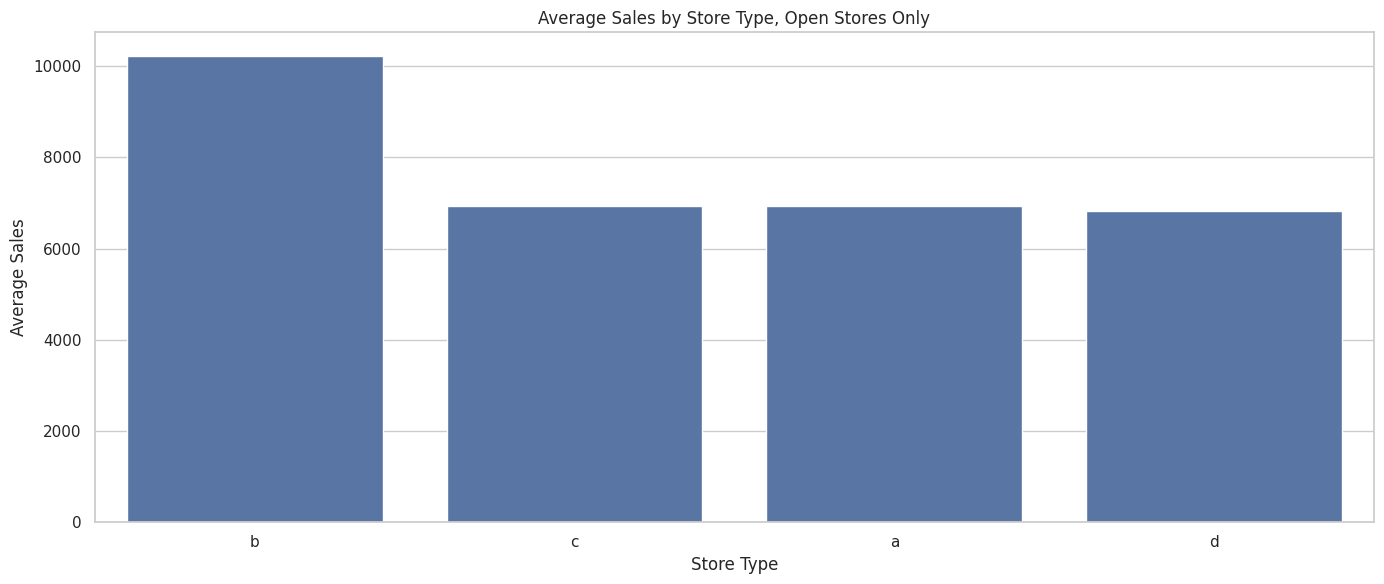

,StoreType,Sales
1,b,"10,231.408"
2,c,"6,932.513"
0,a,"6,925.168"
3,d,"6,822.142"


My decision: I keep store type because store format changes the baseline sales level.


In [10]:
storetype_sales = open_df.groupby("StoreType", as_index=False)["Sales"].mean().sort_values("Sales", ascending=False)

sns.barplot(data=storetype_sales, x="StoreType", y="Sales")
plt.title("Average Sales by Store Type, Open Stores Only")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

display(storetype_sales)

print("My decision: I keep store type because store format changes the baseline sales level.")

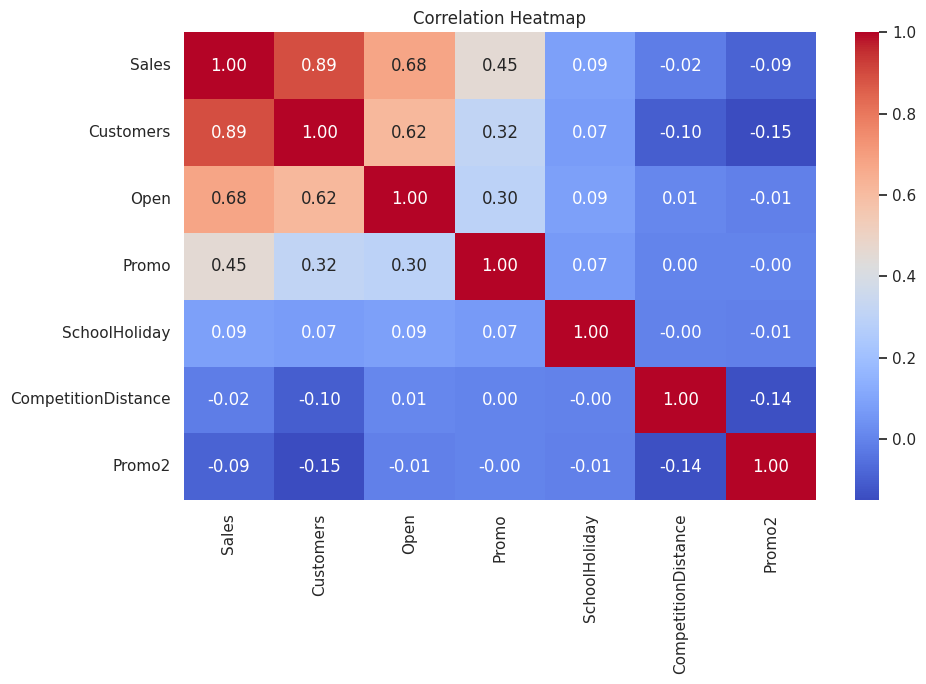

Leakage decision:
- Customers is highly related to Sales.
- But Customers is usually not known before forecasting future sales.
- I exclude Customers from modeling so the project behaves like a real forecast, not a hindsight prediction.


In [11]:
numeric_cols_for_corr = [
    "Sales", "Customers", "Open", "Promo", "SchoolHoliday",
    "CompetitionDistance", "Promo2"
]

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[numeric_cols_for_corr].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Leakage decision:")
print("- Customers is highly related to Sales.")
print("- But Customers is usually not known before forecasting future sales.")
print("- I exclude Customers from modeling so the project behaves like a real forecast, not a hindsight prediction.")

## 4. Feature Engineering

I create features in four groups:

1. Calendar and seasonality  
2. Store and competition context  
3. Promotion and holiday indicators  
4. Historical demand signals  

Important modeling rule: historical demand features must only use sales from previous dates.

In [12]:
model_df = df.copy()

model_df["Year"] = model_df["Date"].dt.year
model_df["Month"] = model_df["Date"].dt.month
model_df["Week"] = model_df["Date"].dt.isocalendar().week.astype(int)
model_df["DayOfWeek"] = model_df["Date"].dt.dayofweek + 1
model_df["IsWeekend"] = model_df["DayOfWeek"].isin([6, 7]).astype(int)

model_df["StateHoliday"] = model_df["StateHoliday"].astype(str)

display(model_df[["Date", "Year", "Month", "Week", "DayOfWeek", "IsWeekend"]].head())

print("Calendar features created.")

,Date,Year,Month,Week,DayOfWeek,IsWeekend
0,2013-01-01,2013,1,1,2,0
1,2013-01-01,2013,1,1,2,0
2,2013-01-01,2013,1,1,2,0
3,2013-01-01,2013,1,1,2,0
4,2013-01-01,2013,1,1,2,0


Calendar features created.


In [13]:
competition_median = model_df["CompetitionDistance"].median()

model_df["CompetitionDistance_filled"] = model_df["CompetitionDistance"].fillna(competition_median)
model_df["CompetitionDistance_km"] = model_df["CompetitionDistance_filled"] / 1000

print(f"Median competition distance used for missing values: {competition_median:,.0f} meters")
display(model_df[["CompetitionDistance", "CompetitionDistance_km"]].head())

Median competition distance used for missing values: 2,330 meters


,CompetitionDistance,CompetitionDistance_km
0,"1,270.000",1.270
1,570.000,0.570
2,"14,130.000",14.130
3,620.000,0.620
4,"29,910.000",29.910


In [14]:
month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sept", 10: "Oct", 11: "Nov", 12: "Dec"
}

model_df["MonthName"] = model_df["Month"].map(month_map)
model_df["PromoInterval"] = model_df["PromoInterval"].fillna("")

model_df["Promo2Active"] = 0

for month_abbr in month_map.values():
    active_mask = (
        (model_df["Promo2"] == 1) &
        (model_df["MonthName"] == month_abbr) &
        (model_df["PromoInterval"].str.contains(month_abbr, regex=False))
    )
    model_df.loc[active_mask, "Promo2Active"] = 1

model_df["PromoActive"] = ((model_df["Promo"] == 1) | (model_df["Promo2Active"] == 1)).astype(int)

display(model_df[["Promo", "Promo2", "PromoInterval", "MonthName", "Promo2Active", "PromoActive"]].head(10))

print("Promotion features created.")
print("I use PromoActive to capture whether the store is under current or extended promotion pressure.")

,Promo,Promo2,PromoInterval,MonthName,Promo2Active,PromoActive
0,0,0,,Jan,0,0
1,0,1,"Jan,Apr,Jul,Oct",Jan,1,1
2,0,1,"Jan,Apr,Jul,Oct",Jan,1,1
3,0,0,,Jan,0,0
4,0,0,,Jan,0,0
5,0,0,,Jan,0,0
6,0,0,,Jan,0,0
7,0,0,,Jan,0,0
8,0,0,,Jan,0,0
9,0,0,,Jan,0,0


Promotion features created.
I use PromoActive to capture whether the store is under current or extended promotion pressure.


In [15]:
model_df["StateHolidayFlag"] = (model_df["StateHoliday"] != "0").astype(int)
model_df["HolidayFlag"] = (
    (model_df["StateHolidayFlag"] == 1) |
    (model_df["SchoolHoliday"] == 1)
).astype(int)

display(model_df[["StateHoliday", "SchoolHoliday", "StateHolidayFlag", "HolidayFlag"]].head(10))

print("Holiday features created.")

,StateHoliday,SchoolHoliday,StateHolidayFlag,HolidayFlag
0,a,1,1,1
1,a,1,1,1
2,a,1,1,1
3,a,1,1,1
4,a,1,1,1
5,a,1,1,1
6,a,1,1,1
7,a,1,1,1
8,a,1,1,1
9,a,1,1,1


Holiday features created.


### Forecasting Assumption for Lag Features

This project is structured as a **rolling daily forecast**.

At each prediction point, the model can use historical sales available before that day, including prior 7-day and 30-day rolling averages.

This mirrors a daily finance planning process where forecasts are refreshed as new actuals arrive.

Important limitation: if this were a one-shot six-week forecast generated only once at the cutoff date, I would need recursive prediction or frozen lag features. Otherwise, the model could accidentally use actual sales from inside the forecast window.


In [16]:
model_df = model_df.sort_values(["Store", "Date"]).reset_index(drop=True)

model_df["Sales_Lag_7_RollingAvg"] = (
    model_df.groupby("Store")["Sales"]
            .transform(lambda s: s.shift(1).rolling(window=7, min_periods=1).mean())
)

model_df["Sales_Lag_30_RollingAvg"] = (
    model_df.groupby("Store")["Sales"]
            .transform(lambda s: s.shift(1).rolling(window=30, min_periods=1).mean())
)

# For the first available rows of each store, there is no prior history.
# I fill those cold-start rows with zero so I do not use future sales information.
lag_cols = ["Sales_Lag_7_RollingAvg", "Sales_Lag_30_RollingAvg"]
model_df[lag_cols] = model_df[lag_cols].fillna(0)

display(model_df[["Store", "Date", "Sales", "Sales_Lag_7_RollingAvg", "Sales_Lag_30_RollingAvg"]].head(12))

print("Lag features created using only prior sales within each store.")

,Store,Date,Sales,Sales_Lag_7_RollingAvg,Sales_Lag_30_RollingAvg
0,1,2013-01-01,0,0.000,0.000
1,1,2013-01-02,5530,0.000,0.000
2,1,2013-01-03,4327,"2,765.000","2,765.000"
3,1,2013-01-04,4486,"3,285.667","3,285.667"
4,1,2013-01-05,4997,"3,585.750","3,585.750"
5,1,2013-01-06,0,"3,868.000","3,868.000"
6,1,2013-01-07,7176,"3,223.333","3,223.333"
7,1,2013-01-08,5580,"3,788.000","3,788.000"
8,1,2013-01-09,5471,"4,585.143","4,012.000"
9,1,2013-01-10,4892,"4,576.714","4,174.111"


Lag features created using only prior sales within each store.


### Final Feature Set and Leakage Control

The feature set combines future-known planning variables, store context, and historical demand signals.

I intentionally exclude `Customers`.

`Customers` is highly predictive of sales, but in a real forecast it would usually not be known before the forecast date. Including it would make the model look better in the notebook while making it unrealistic for production planning.


In [17]:
numeric_features = [
    "Open",
    "Promo",
    "SchoolHoliday",
    "Year",
    "Month",
    "Week",
    "DayOfWeek",
    "IsWeekend",
    "CompetitionDistance_km",
    "Promo2Active",
    "PromoActive",
    "HolidayFlag",
    "Sales_Lag_7_RollingAvg",
    "Sales_Lag_30_RollingAvg"
]

categorical_features = [
    "Store",
    "StoreType",
    "Assortment",
    "StateHoliday"
]

feature_columns = numeric_features + categorical_features
target_column = "Sales"

feature_plan = pd.DataFrame({
    "Feature": feature_columns + ["Customers"],
    "Type": (
        ["Numeric / future-known or historical"] * len(numeric_features) +
        ["Categorical / store context"] * len(categorical_features) +
        ["Excluded"]
    ),
    "Reason": (
        ["Planning or historical demand signal"] * len(numeric_features) +
        ["Store-level business context"] * len(categorical_features) +
        ["Excluded because it is usually unknown before the forecast date"]
    )
})

display(feature_plan)

,Feature,Type,Reason
0,Open,Numeric / future-known or historical,Planning or historical demand signal
1,Promo,Numeric / future-known or historical,Planning or historical demand signal
2,SchoolHoliday,Numeric / future-known or historical,Planning or historical demand signal
3,Year,Numeric / future-known or historical,Planning or historical demand signal
4,Month,Numeric / future-known or historical,Planning or historical demand signal
5,Week,Numeric / future-known or historical,Planning or historical demand signal
6,DayOfWeek,Numeric / future-known or historical,Planning or historical demand signal
7,IsWeekend,Numeric / future-known or historical,Planning or historical demand signal
8,CompetitionDistance_km,Numeric / future-known or historical,Planning or historical demand signal
9,Promo2Active,Numeric / future-known or historical,Planning or historical demand signal


## 5. Time-Based Validation Split

I use the last six weeks as the test window.

This is closer to a real forecasting workflow than a random split because the model trains on the past and predicts a future time period.

This also makes the evaluation harder and more realistic: the model must generalize forward in time instead of seeing randomly mixed historical dates during training and testing.


In [18]:
max_date = model_df["Date"].max()
cutoff_date = max_date - pd.Timedelta(weeks=6)

train_df = model_df[model_df["Date"] <= cutoff_date].copy()
test_df = model_df[model_df["Date"] > cutoff_date].copy()

X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target_column].copy()

print("Max date:", max_date.date())
print("Cutoff date:", cutoff_date.date())
print("Train period:", train_df["Date"].min().date(), "to", train_df["Date"].max().date())
print("Test period:", test_df["Date"].min().date(), "to", test_df["Date"].max().date())
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Max date: 2015-07-31
Cutoff date: 2015-06-19
Train period: 2013-01-01 to 2015-06-19
Test period: 2015-06-20 to 2015-07-31
Train shape: (970379, 18)
Test shape: (46830, 18)


## 6. Modeling Utilities

I evaluate models using both machine learning and finance-friendly metrics.

- **RMSE:** penalizes large forecast errors  
- **MAE:** average absolute error  
- **WAPE:** total absolute error as a share of total actual sales  
- **Forecast Bias:** whether the model over-forecasts or under-forecasts in aggregate  
- **R²:** variance explained

In [19]:
def build_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", build_one_hot_encoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.maximum(np.asarray(y_pred), 0)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    denominator = np.sum(np.abs(y_true))
    wape = np.sum(np.abs(y_true - y_pred)) / denominator if denominator != 0 else np.nan
    forecast_bias = np.sum(y_pred - y_true) / denominator if denominator != 0 else np.nan

    return {
        "RMSE": rmse,
        "MAE": mae,
        "WAPE": wape,
        "Forecast Bias": forecast_bias,
        "R2": r2
    }

def format_metric_table(df):
    return df.style.format({
        "RMSE": "{:,.2f}",
        "MAE": "{:,.2f}",
        "WAPE": "{:.2%}",
        "Forecast Bias": "{:.2%}",
        "R2": "{:.4f}"
    })

print("Preprocessing and evaluation functions are ready.")

Preprocessing and evaluation functions are ready.


## 7. Naive Business Baseline

Before training machine learning models, I compare against a simple planning baseline:  
**predict tomorrow using the prior seven-day rolling sales average.**

This is important because a model is only useful if it beats a simple business rule.

In [20]:
naive_pred = X_test["Sales_Lag_7_RollingAvg"].values
naive_metrics = evaluate_regression(y_test, naive_pred)

print("Naive 7-Day Rolling Average Baseline")
for metric, value in naive_metrics.items():
    if metric in ["WAPE", "Forecast Bias"]:
        print(f"{metric}: {value:.2%}")
    else:
        print(f"{metric}: {value:,.4f}")

Naive 7-Day Rolling Average Baseline
RMSE: 3,188.9335
MAE: 2,192.4521
WAPE: 36.52%
Forecast Bias: -0.48%
R2: 0.2675


## 8. Linear Regression Baseline

I use linear regression as an interpretable statistical baseline.  
It helps me understand whether a simple additive model is enough before moving to nonlinear models.

In [21]:
linear_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)
linear_pred = np.maximum(linear_pred, 0)

linear_metrics = evaluate_regression(y_test, linear_pred)

print("Linear Regression Test Performance")
for metric, value in linear_metrics.items():
    if metric in ["WAPE", "Forecast Bias"]:
        print(f"{metric}: {value:.2%}")
    else:
        print(f"{metric}: {value:,.4f}")

Linear Regression Test Performance
RMSE: 1,428.0310
MAE: 955.9446
WAPE: 15.92%
Forecast Bias: 3.71%
R2: 0.8531


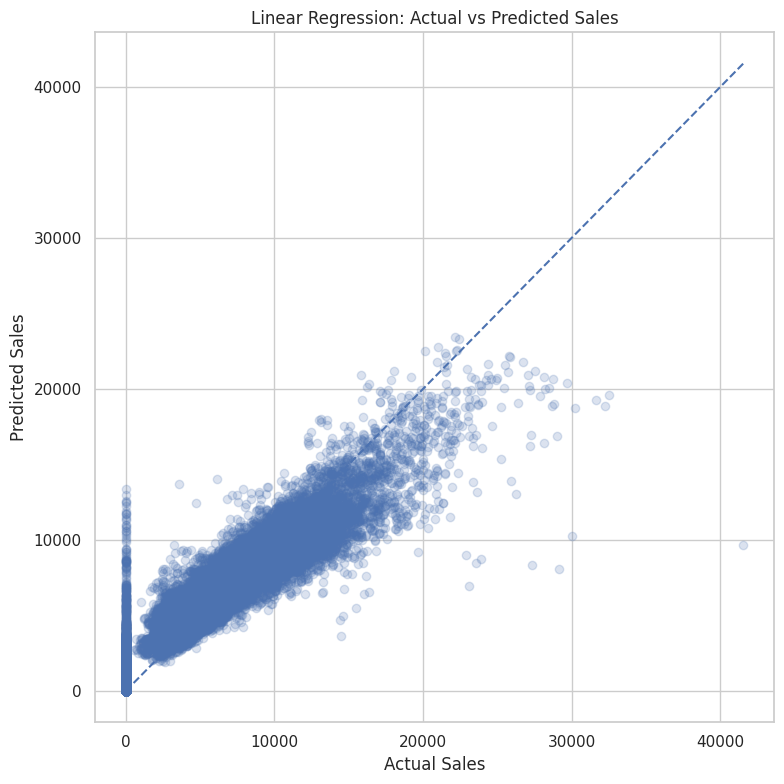

Model read:
The linear model is useful as a baseline, but large deviations from the diagonal suggest nonlinear behavior.


In [22]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, linear_pred, alpha=0.2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title("Linear Regression: Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.tight_layout()
plt.show()

print("Model read:")
print("The linear model is useful as a baseline, but large deviations from the diagonal suggest nonlinear behavior.")

In [23]:
linear_preprocessor = linear_model.named_steps["preprocess"]
linear_estimator = linear_model.named_steps["model"]

feature_names = linear_preprocessor.get_feature_names_out()
clean_feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

coef_df = pd.DataFrame({
    "Feature": clean_feature_names,
    "Coefficient": linear_estimator.coef_
})

coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
display(coef_df.sort_values("AbsCoefficient", ascending=False).head(15))

print("Interpretation note:")
print("Coefficients are directional for the linear model, but they do not capture nonlinear interactions or causal effects.")

,Feature,Coefficient,AbsCoefficient
0,Open,"5,570.324","5,570.324"
1,Promo,"1,918.584","1,918.584"
1136,StateHoliday_0,885.038,885.038
7,IsWeekend,790.786,790.786
1138,StateHoliday_b,-543.466,543.466
1139,StateHoliday_c,-479.874,479.874
1130,StoreType_b,-312.545,312.545
6,DayOfWeek,-304.053,304.053
10,PromoActive,299.891,299.891
9,Promo2Active,-285.152,285.152


Interpretation note:
Coefficients are directional for the linear model, but they do not capture nonlinear interactions or causal effects.


## 9. XGBoost Forecasting Model

I use XGBoost because retail sales often contain nonlinear patterns:

- Promotion effects can differ by store type  
- Holiday effects can interact with day of week  
- Recent demand can behave differently across stores  
- Store format and competition can shift baseline demand

In [24]:
xgb_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_pred = np.maximum(xgb_pred, 0)

xgb_metrics = evaluate_regression(y_test, xgb_pred)

print("XGBoost Test Performance")
for metric, value in xgb_metrics.items():
    if metric in ["WAPE", "Forecast Bias"]:
        print(f"{metric}: {value:.2%}")
    else:
        print(f"{metric}: {value:,.4f}")

XGBoost Test Performance
RMSE: 966.4862
MAE: 630.5392
WAPE: 10.50%
Forecast Bias: 2.03%
R2: 0.9327


In [25]:
model_performance = pd.DataFrame([
    {"Model": "Naive 7-Day Rolling Avg", **naive_metrics},
    {"Model": "Linear Regression", **linear_metrics},
    {"Model": "XGBoost", **xgb_metrics}
])

display(format_metric_table(model_performance))

linear_rmse = model_performance.loc[model_performance["Model"] == "Linear Regression", "RMSE"].iloc[0]
naive_rmse = model_performance.loc[model_performance["Model"] == "Naive 7-Day Rolling Avg", "RMSE"].iloc[0]
xgb_rmse = model_performance.loc[model_performance["Model"] == "XGBoost", "RMSE"].iloc[0]

xgb_vs_linear = (linear_rmse - xgb_rmse) / linear_rmse * 100
xgb_vs_naive = (naive_rmse - xgb_rmse) / naive_rmse * 100

print(f"XGBoost RMSE improvement vs Linear Regression: {xgb_vs_linear:,.1f}%")
print(f"XGBoost RMSE improvement vs Naive Baseline: {xgb_vs_naive:,.1f}%")

,Model,RMSE,MAE,WAPE,Forecast Bias,R2
0,Naive 7-Day Rolling Avg,"3,188.93","2,192.45",36.52%,-0.48%,0.2675
1,Linear Regression,"1,428.03",955.94,15.92%,3.71%,0.8531
2,XGBoost,966.49,630.54,10.50%,2.03%,0.9327


XGBoost RMSE improvement vs Linear Regression: 32.3%
XGBoost RMSE improvement vs Naive Baseline: 69.7%


In [26]:
# Error analysis by store and business driver
error_df = test_df[[
    "Date",
    "Store",
    "StoreType",
    "Promo",
    "DayOfWeek",
    "SchoolHoliday",
    "Sales"
]].copy()

error_df = error_df.rename(columns={"Sales": "Actual"})
error_df["Predicted"] = xgb_pred
error_df["Error"] = error_df["Predicted"] - error_df["Actual"]
error_df["AbsError"] = error_df["Error"].abs()
error_df["AbsPctError"] = np.where(
    error_df["Actual"] > 0,
    error_df["AbsError"] / error_df["Actual"],
    np.nan
)

def summarize_forecast_error(group):
    actual_sum = group["Actual"].sum()
    pred_sum = group["Predicted"].sum()
    abs_error_sum = group["AbsError"].sum()

    return pd.Series({
        "Actual Sales": actual_sum,
        "Predicted Sales": pred_sum,
        "MAE": group["AbsError"].mean(),
        "WAPE": abs_error_sum / actual_sum if actual_sum != 0 else np.nan,
        "Forecast Bias": (pred_sum - actual_sum) / actual_sum if actual_sum != 0 else np.nan
    })

store_error = (
    error_df
    .groupby("Store")
    .apply(summarize_forecast_error)
    .reset_index()
    .sort_values("WAPE", ascending=False)
)

print("Top 10 stores with highest WAPE")
display(
    store_error.head(10).style.format({
        "Actual Sales": "${:,.0f}",
        "Predicted Sales": "${:,.0f}",
        "MAE": "{:,.2f}",
        "WAPE": "{:.2%}",
        "Forecast Bias": "{:.2%}"
    })
)

promo_error = (
    error_df
    .groupby("Promo")
    .apply(summarize_forecast_error)
    .reset_index()
)

print("\nForecast error by promotion status")
display(
    promo_error.style.format({
        "Actual Sales": "${:,.0f}",
        "Predicted Sales": "${:,.0f}",
        "MAE": "{:,.2f}",
        "WAPE": "{:.2%}",
        "Forecast Bias": "{:.2%}"
    })
)

day_error = (
    error_df
    .groupby("DayOfWeek")
    .apply(summarize_forecast_error)
    .reset_index()
)

print("\nForecast error by day of week")
display(
    day_error.style.format({
        "Actual Sales": "${:,.0f}",
        "Predicted Sales": "${:,.0f}",
        "MAE": "{:,.2f}",
        "WAPE": "{:.2%}",
        "Forecast Bias": "{:.2%}"
    })
)


Top 10 stores with highest WAPE


,Store,Actual Sales,Predicted Sales,MAE,WAPE,Forecast Bias
291,292,"$131,910","$132,284","1,910.44",60.83%,0.28%
908,909,"$348,213","$246,944","4,807.66",57.99%,-29.08%
875,876,"$247,635","$240,140","2,736.19",46.41%,-3.03%
574,575,"$185,049","$191,661","1,037.40",23.55%,3.57%
635,636,"$237,505","$238,604","1,300.48",23.00%,0.46%
182,183,"$188,887","$178,963",953.95,21.21%,-5.25%
482,483,"$170,309","$179,018",830.55,20.48%,5.11%
270,271,"$274,745","$283,368","1,331.82",20.36%,3.14%
898,899,"$177,078","$187,148",838.12,19.88%,5.69%
969,970,"$99,563","$110,936",463.12,19.54%,11.42%



Forecast error by promotion status


,Promo,Actual Sales,Predicted Sales,MAE,WAPE,Forecast Bias
0,0,"$139,254,599","$142,638,592",523.62,11.32%,2.43%
1,1,"$141,858,899","$144,170,720",822.99,9.70%,1.63%



Forecast error by day of week


,DayOfWeek,Actual Sales,Predicted Sales,MAE,WAPE,Forecast Bias
0,1,"$54,897,563","$55,694,020",824.14,10.04%,1.45%
1,2,"$48,981,288","$48,816,128",690.51,9.43%,-0.34%
2,3,"$45,529,208","$46,211,820",593.30,8.72%,1.50%
3,4,"$45,456,034","$46,461,296",585.02,8.61%,2.21%
4,5,"$46,890,388","$48,126,624",694.99,9.92%,2.64%
5,6,"$37,715,921","$39,845,008",985.63,17.48%,5.65%
6,7,"$1,643,096","$1,654,413",40.19,16.36%,0.69%


### Error Analysis Insight

I do not stop at the global accuracy number because a finance model can look strong overall and still fail in specific operating pockets.

I inspect error by:

- **Store:** identifies locations with unstable or harder-to-predict demand  
- **Promotion status:** checks whether promo periods are systematically harder to forecast  
- **Day of week:** checks whether weekly operating patterns are creating forecast risk  

This is the part I would use in a real business review to decide where the model needs more features, store-specific treatment, or operational follow-up.


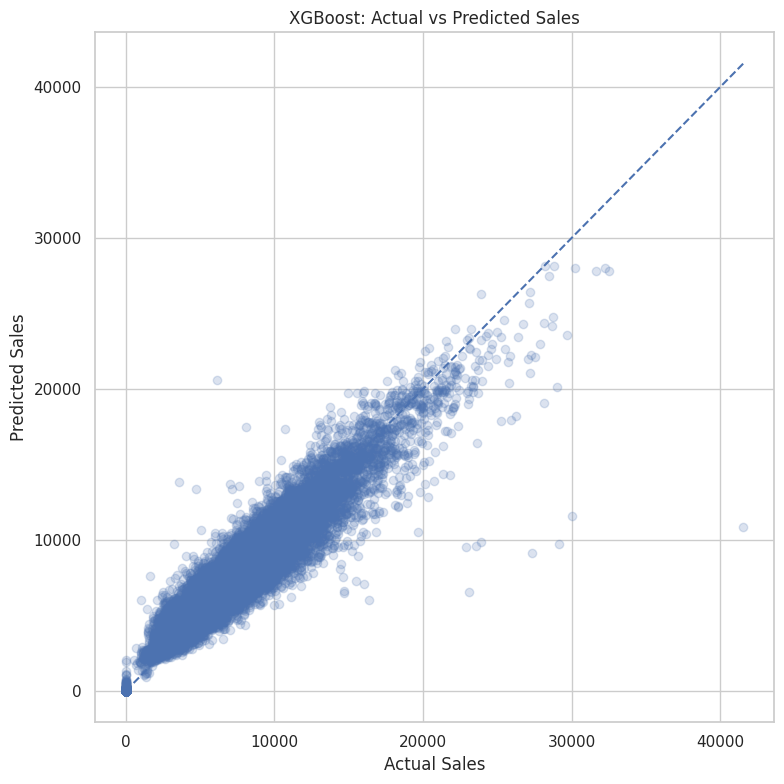

In [27]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, xgb_pred, alpha=0.2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title("XGBoost: Actual vs Predicted Sales")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.tight_layout()
plt.show()

## 10. Feature Importance

Feature importance helps identify what the model relied on.  
I separate raw features from grouped business drivers because one-hot encoded store IDs can dominate the technical view.

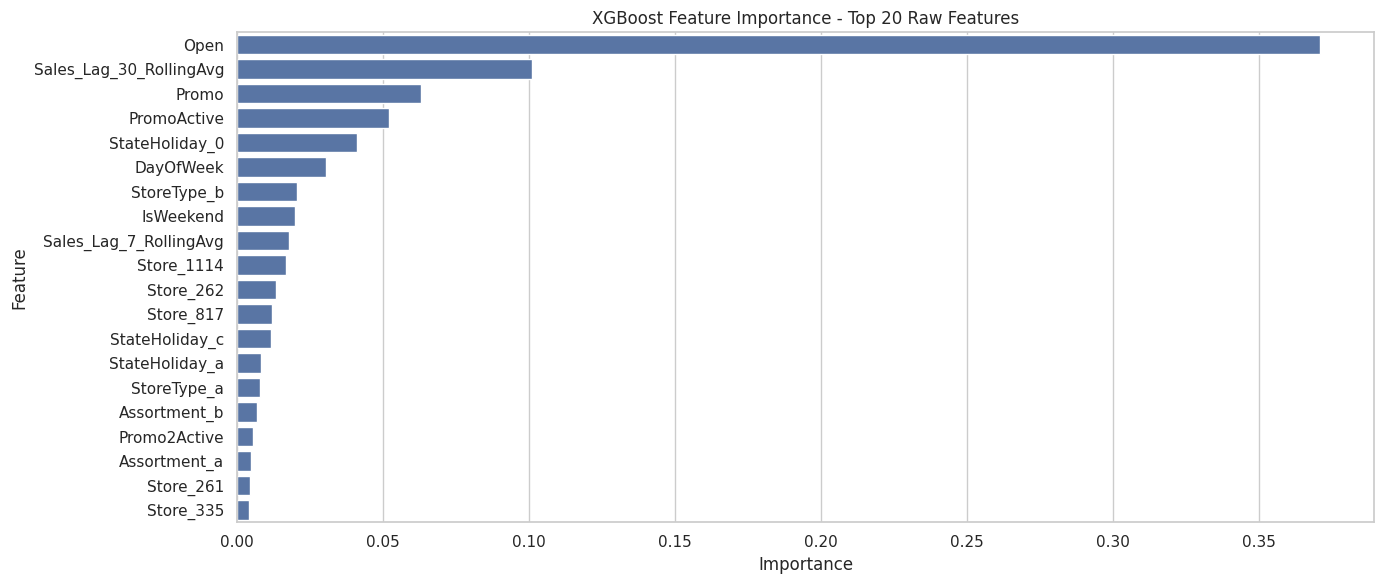

,Feature,Importance
0,Open,0.371
13,Sales_Lag_30_RollingAvg,0.101
1,Promo,0.063
10,PromoActive,0.052
1136,StateHoliday_0,0.041
6,DayOfWeek,0.030
1130,StoreType_b,0.021
7,IsWeekend,0.020
12,Sales_Lag_7_RollingAvg,0.018
1127,Store_1114,0.017


Interpretation note:
Raw feature importance shows model usage, not causality. Store IDs represent fixed store effects, not direct business levers.


In [28]:
xgb_preprocessor = xgb_model.named_steps["preprocess"]
xgb_estimator = xgb_model.named_steps["model"]

xgb_feature_names = xgb_preprocessor.get_feature_names_out()
xgb_clean_feature_names = [name.replace("num__", "").replace("cat__", "") for name in xgb_feature_names]

importance_df = pd.DataFrame({
    "Feature": xgb_clean_feature_names,
    "Importance": xgb_estimator.feature_importances_
}).sort_values("Importance", ascending=False)

top_20_importance = importance_df.head(20)

sns.barplot(data=top_20_importance, x="Importance", y="Feature")
plt.title("XGBoost Feature Importance - Top 20 Raw Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(top_20_importance)

print("Interpretation note:")
print("Raw feature importance shows model usage, not causality. Store IDs represent fixed store effects, not direct business levers.")

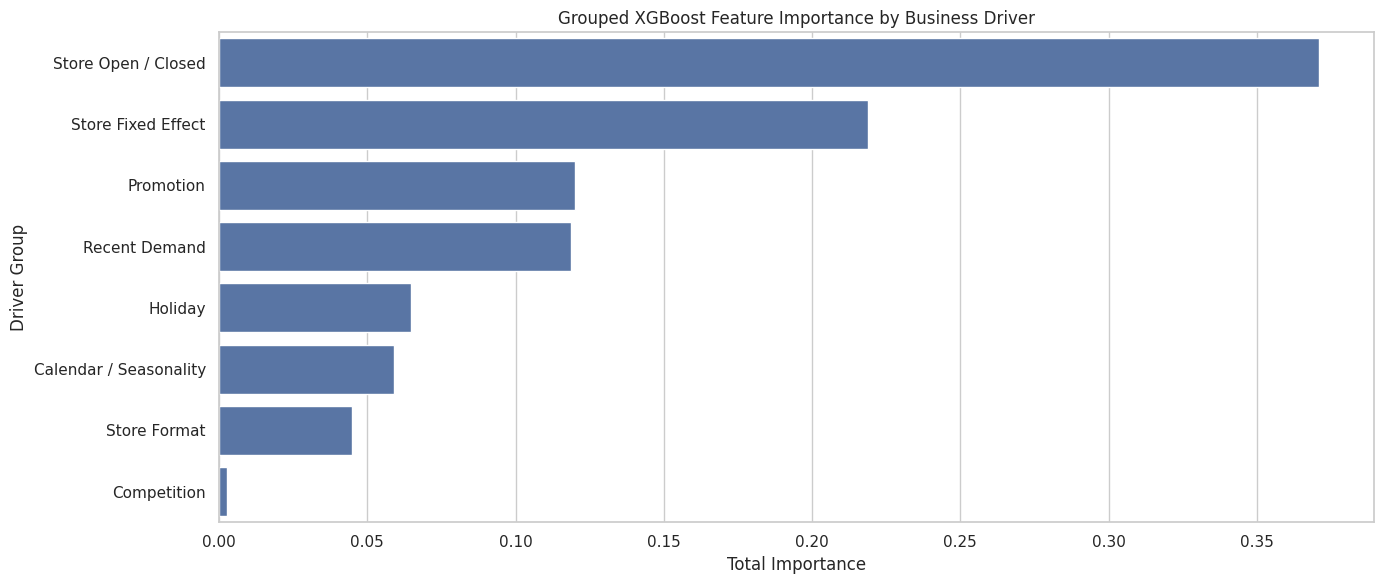

,Driver Group,Importance
7,Store Open / Closed,0.371
5,Store Fixed Effect,0.219
3,Promotion,0.120
4,Recent Demand,0.119
2,Holiday,0.065
0,Calendar / Seasonality,0.059
6,Store Format,0.045
1,Competition,0.003


Business view:
I use the grouped view to separate actionable planning drivers from fixed store-level effects.


In [29]:
def map_feature_group(feature):
    if "Sales_Lag" in feature:
        return "Recent Demand"
    if feature in ["Promo", "Promo2Active", "PromoActive"] or "Promo" in feature:
        return "Promotion"
    if "Holiday" in feature or "StateHoliday" in feature or feature == "SchoolHoliday":
        return "Holiday"
    if "Competition" in feature:
        return "Competition"
    if "StoreType" in feature or "Assortment" in feature:
        return "Store Format"
    if feature in ["Year", "Month", "Week", "DayOfWeek", "IsWeekend"]:
        return "Calendar / Seasonality"
    if feature.startswith("Store_"):
        return "Store Fixed Effect"
    if feature == "Open":
        return "Store Open / Closed"
    return "Other"

importance_df["Driver Group"] = importance_df["Feature"].apply(map_feature_group)

grouped_importance = (
    importance_df
    .groupby("Driver Group", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

sns.barplot(data=grouped_importance, x="Importance", y="Driver Group")
plt.title("Grouped XGBoost Feature Importance by Business Driver")
plt.xlabel("Total Importance")
plt.ylabel("Driver Group")
plt.tight_layout()
plt.show()

display(grouped_importance)

print("Business view:")
print("I use the grouped view to separate actionable planning drivers from fixed store-level effects.")

## 11. Production Considerations

If this model were deployed in a real finance planning workflow, I would not treat model training as the finish line.

### Data pipeline

- Refresh sales, promotions, holiday, and store metadata daily.
- Run automated data quality checks before scoring.
- Block or alert on schema changes, missing dates, missing stores, or abnormal zero-sales spikes.

### Retraining plan

- Retrain weekly or monthly depending on how quickly demand patterns shift.
- Revalidate after major holidays, promotion calendar changes, or store portfolio changes.

### Monitoring

I would track:

- **WAPE over time** to monitor aggregate forecast accuracy  
- **Forecast bias** to detect systematic over-forecasting or under-forecasting  
- **Error by store and promotion status** to catch localized model weakness  
- **Feature drift** in promotions, holidays, store open status, and recent demand signals  

### Fallback strategy

If the model fails, drifts, or receives unreliable input data, I would fall back to the naive 7-day rolling-average baseline.

This matters because finance users need reliability and explainability, not only a high-performing model in a notebook.


## 12. Scenario Simulation

This is the business planning layer.

I use the trained XGBoost model to simulate four cases over the six-week test window:

1. **Baseline forecast**  
2. **No promotions**  
3. **Full promotions**  
4. **15% demand drop through lagged-demand signals**  

### Scenario Assumptions

These scenarios represent model-based sensitivity, not causal impact.

For example, if the full-promotion scenario increases forecasted revenue, that means the model learned that promotion periods are historically associated with higher sales. It does not prove that promotions caused the full increase.

To estimate true causal promotion impact, I would use A/B testing, matched controls, difference-in-differences, or another causal inference approach.


In [30]:
def simulate_scenario(base_features, model_pipeline, scenario_name, change_function=None):
    scenario_features = base_features.copy()

    if change_function is not None:
        scenario_features = change_function(scenario_features)

    predictions = model_pipeline.predict(scenario_features)
    predictions = np.maximum(predictions, 0)

    total_revenue = predictions.sum()

    scenario_daily = pd.DataFrame({
        "Date": test_df["Date"].values,
        "Store": test_df["Store"].values,
        "Scenario": scenario_name,
        "PredictedSales": predictions
    })

    return total_revenue, scenario_daily


X_test_raw = X_test.copy()

def no_promotions(features):
    features = features.copy()
    features["PromoActive"] = 0
    features["Promo"] = 0
    features["Promo2Active"] = 0
    return features

def full_promotions(features):
    features = features.copy()
    features["PromoActive"] = 1
    features["Promo"] = 1
    features["Promo2Active"] = 1
    return features

def demand_drop(features):
    features = features.copy()
    features["Sales_Lag_7_RollingAvg"] = features["Sales_Lag_7_RollingAvg"] * 0.85
    features["Sales_Lag_30_RollingAvg"] = features["Sales_Lag_30_RollingAvg"] * 0.85
    return features

scenario_configs = [
    ("Baseline", None),
    ("No Promotions", no_promotions),
    ("Full Promotions", full_promotions),
    ("Demand Drop -15%", demand_drop)
]

scenario_rows = []
scenario_daily_list = []
baseline_revenue = None

for scenario_name, change_function in scenario_configs:
    total_revenue, daily_output = simulate_scenario(
        X_test_raw,
        xgb_model,
        scenario_name,
        change_function
    )

    if scenario_name == "Baseline":
        baseline_revenue = total_revenue

    scenario_rows.append({
        "Scenario": scenario_name,
        "Forecasted Revenue": total_revenue
    })

    scenario_daily_list.append(daily_output)

scenario_summary = pd.DataFrame(scenario_rows)
scenario_summary["vs Baseline"] = scenario_summary["Forecasted Revenue"] - baseline_revenue
scenario_summary["% Change"] = scenario_summary["vs Baseline"] / baseline_revenue

display(
    scenario_summary.style.format({
        "Forecasted Revenue": "${:,.0f}",
        "vs Baseline": "${:,.0f}",
        "% Change": "{:.2%}"
    })
)

print("Scenario interpretation:")
print("This converts the model from a prediction tool into a finance planning tool.")
print("These results should be read as model-estimated sensitivity, not causal promotion impact.")

,Scenario,Forecasted Revenue,vs Baseline,% Change
0,Baseline,"$286,809,312",$0,0.00%
1,No Promotions,"$247,802,960","$-39,006,352",-13.60%
2,Full Promotions,"$334,098,016","$47,288,704",16.49%
3,Demand Drop -15%,"$245,658,480","$-41,150,832",-14.35%


Scenario interpretation:
This converts the model from a prediction tool into a finance planning tool.
These results should be read as model-estimated sensitivity, not causal promotion impact.


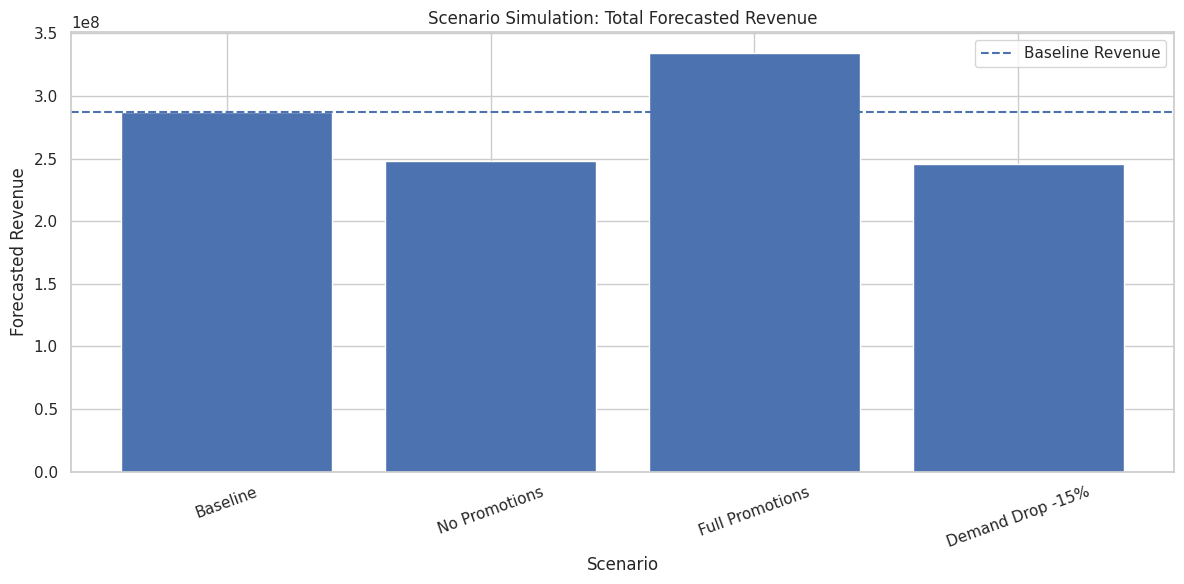

In [31]:
plt.figure(figsize=(12, 6))
plt.bar(scenario_summary["Scenario"], scenario_summary["Forecasted Revenue"])
plt.axhline(baseline_revenue, linestyle="--", label="Baseline Revenue")
plt.title("Scenario Simulation: Total Forecasted Revenue")
plt.xlabel("Scenario")
plt.ylabel("Forecasted Revenue")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

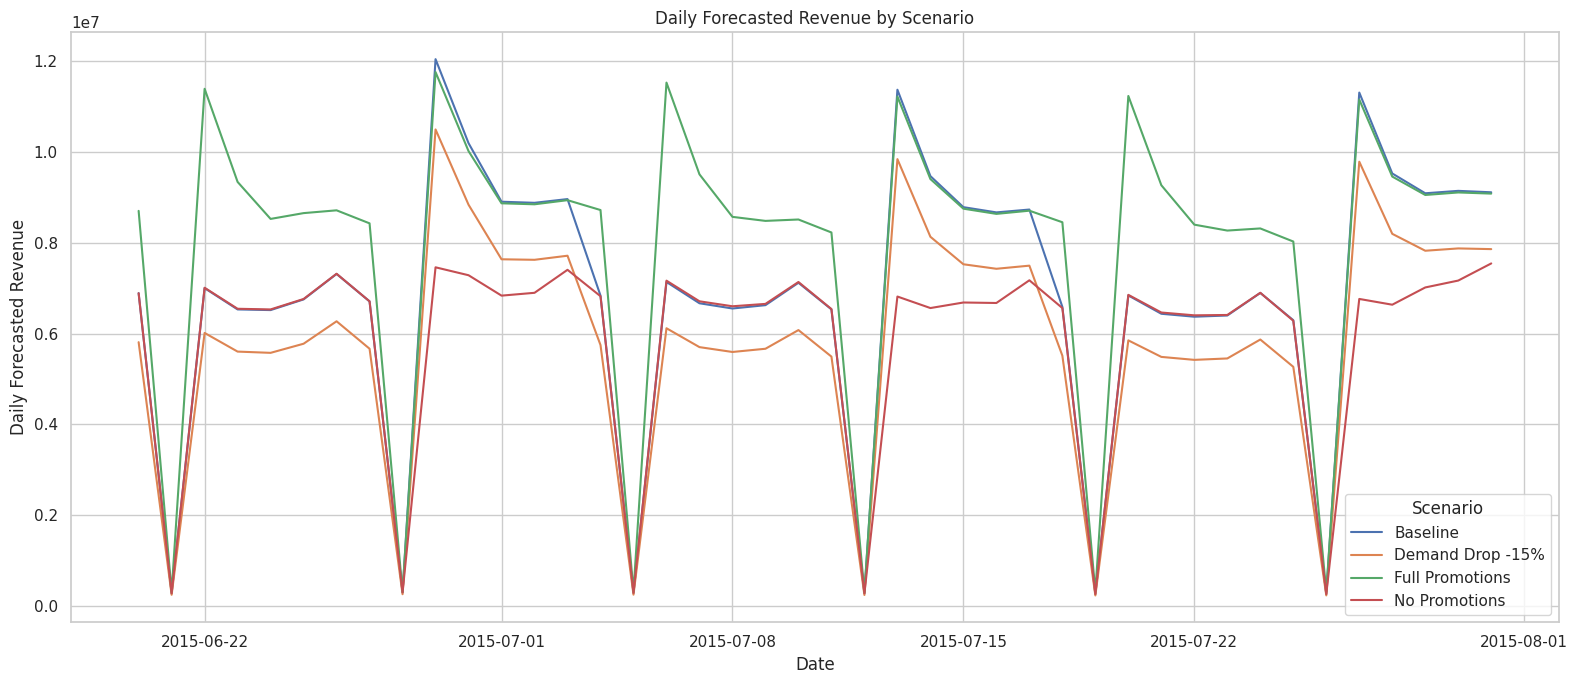

In [32]:
scenario_daily_df = pd.concat(scenario_daily_list, ignore_index=True)

daily_scenario_sales = (
    scenario_daily_df
    .groupby(["Date", "Scenario"], as_index=False)["PredictedSales"]
    .sum()
)

plt.figure(figsize=(16, 7))
sns.lineplot(data=daily_scenario_sales, x="Date", y="PredictedSales", hue="Scenario")
plt.title("Daily Forecasted Revenue by Scenario")
plt.xlabel("Date")
plt.ylabel("Daily Forecasted Revenue")
plt.tight_layout()
plt.show()

## Business Recommendations

Based on the model results and scenario layer:

1. **Use the XGBoost model for planning support, not as a black-box decision maker.**  
   It outperforms simple baselines and captures nonlinear business patterns, but it still needs monitoring and business review.

2. **Use promotion scenarios as planning sensitivity, not causal ROI.**  
   The model can estimate how revenue forecasts move under promotion assumptions, but margin and causal lift need separate validation.

3. **Prioritize investigation of high-error stores.**  
   Stores with the highest WAPE may need additional local features, store-specific overrides, or closer operational review.

4. **Monitor forecast bias before using the model for staffing, inventory, or financial planning.**  
   Persistent over-forecasting can lead to over-planning; persistent under-forecasting can lead to missed demand.

5. **Separate prediction drivers from actionable business levers.**  
   Store ID can improve accuracy by capturing fixed store effects, but decisions should focus on interpretable drivers like promotions, holidays, recent demand, store format, and competition.


## 13. SHAP Explainability

SHAP helps explain model-attributed drivers at the prediction level.

Important interpretation rule:  
SHAP explains how the model used the features. It does not prove that a feature caused sales to change.

In [33]:
shap_sample_size = min(3000, len(X_test))
X_shap_raw = X_test.sample(shap_sample_size, random_state=RANDOM_STATE)

X_shap_processed = xgb_model.named_steps["preprocess"].transform(X_shap_raw)

if hasattr(X_shap_processed, "toarray"):
    X_shap_processed_dense = X_shap_processed.toarray()
else:
    X_shap_processed_dense = X_shap_processed

shap_feature_names = xgb_model.named_steps["preprocess"].get_feature_names_out()
shap_clean_names = [name.replace("num__", "").replace("cat__", "") for name in shap_feature_names]

explainer = shap.TreeExplainer(xgb_model.named_steps["model"])
shap_values = explainer.shap_values(X_shap_processed_dense)

print("SHAP values calculated.")
print("SHAP sample shape:", X_shap_processed_dense.shape)

SHAP values calculated.
SHAP sample shape: (3000, 1140)


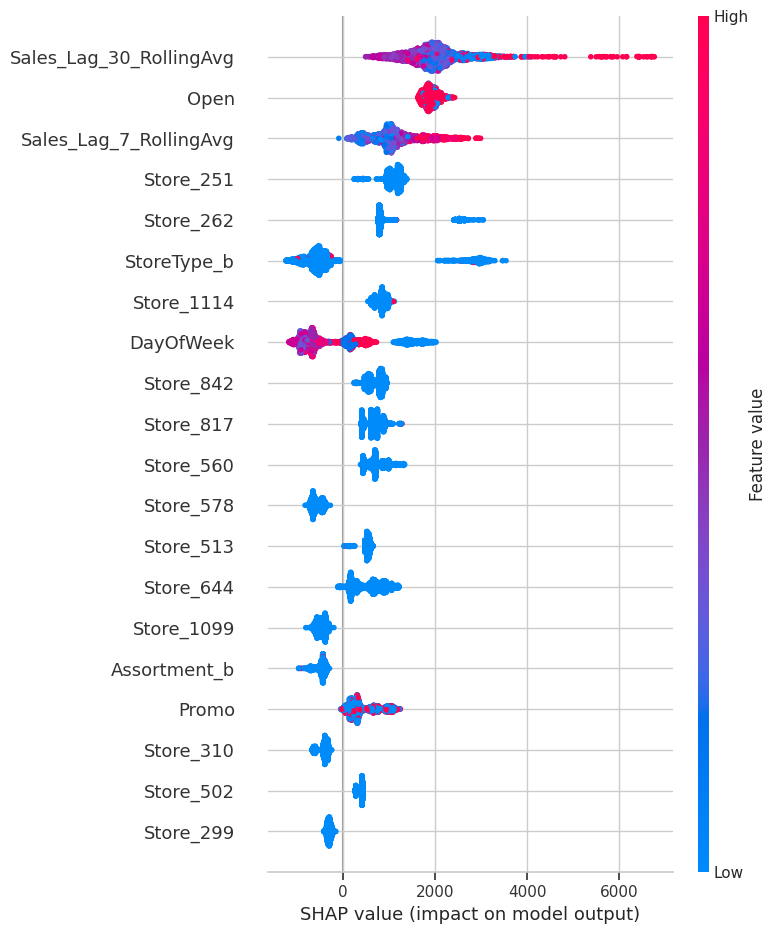

In [34]:
shap.summary_plot(
    shap_values,
    X_shap_processed_dense,
    feature_names=shap_clean_names,
    show=True
)

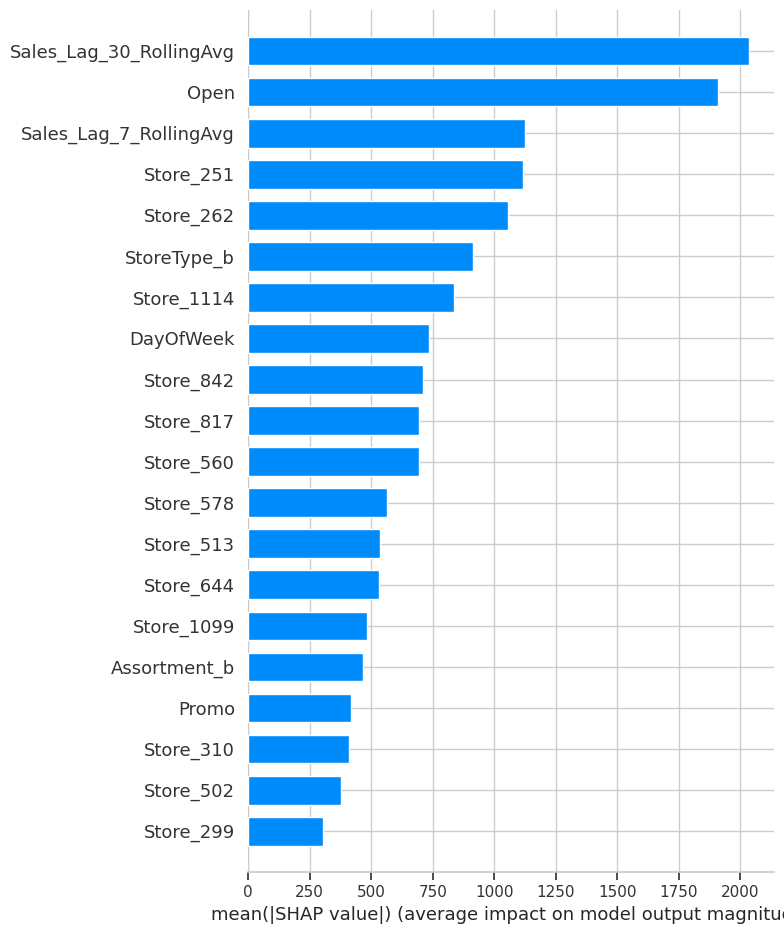

In [35]:
shap.summary_plot(
    shap_values,
    X_shap_processed_dense,
    feature_names=shap_clean_names,
    plot_type="bar",
    show=True
)

In [36]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_impact_df = pd.DataFrame({
    "Feature": shap_clean_names,
    "Mean Absolute SHAP Impact": mean_abs_shap
}).sort_values("Mean Absolute SHAP Impact", ascending=False)

shap_impact_df["Driver Group"] = shap_impact_df["Feature"].apply(map_feature_group)

display(shap_impact_df.head(15))

print("Top SHAP findings in business English:")
for _, row in shap_impact_df.head(5).iterrows():
    print(
        f"- {row['Feature']} changes predicted daily sales by about "
        f"${row['Mean Absolute SHAP Impact']:,.0f} on average in the model."
    )

print("I describe this as model-attributed impact, not causal impact.")

,Feature,Mean Absolute SHAP Impact,Driver Group
13,Sales_Lag_30_RollingAvg,"2,035.222",Recent Demand
0,Open,"1,907.397",Store Open / Closed
12,Sales_Lag_7_RollingAvg,"1,126.286",Recent Demand
264,Store_251,"1,116.991",Store Fixed Effect
275,Store_262,"1,057.718",Store Fixed Effect
1130,StoreType_b,912.918,Store Format
1127,Store_1114,836.212,Store Fixed Effect
6,DayOfWeek,733.149,Calendar / Seasonality
855,Store_842,710.052,Store Fixed Effect
830,Store_817,694.612,Store Fixed Effect


Top SHAP findings in business English:
- Sales_Lag_30_RollingAvg changes predicted daily sales by about $2,035 on average in the model.
- Open changes predicted daily sales by about $1,907 on average in the model.
- Sales_Lag_7_RollingAvg changes predicted daily sales by about $1,126 on average in the model.
- Store_251 changes predicted daily sales by about $1,117 on average in the model.
- Store_262 changes predicted daily sales by about $1,058 on average in the model.
I describe this as model-attributed impact, not causal impact.


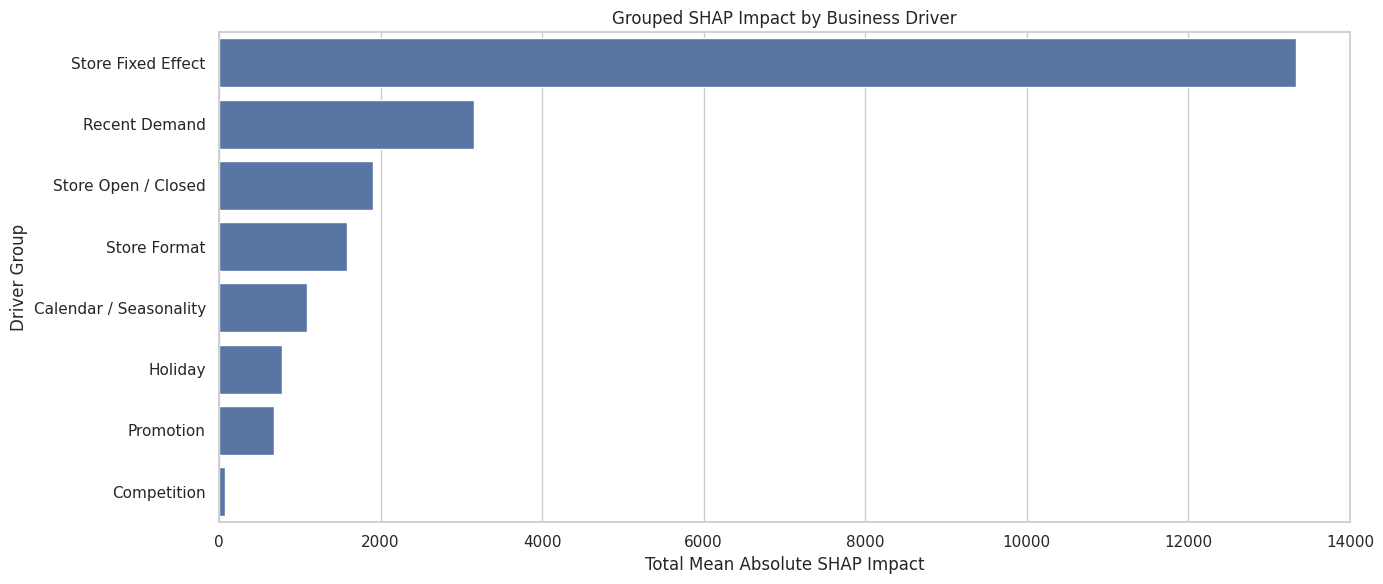

,Driver Group,Mean Absolute SHAP Impact
5,Store Fixed Effect,"13,333.953"
4,Recent Demand,"3,161.508"
7,Store Open / Closed,"1,907.397"
6,Store Format,"1,579.757"
0,Calendar / Seasonality,"1,085.205"
2,Holiday,774.662
3,Promotion,676.934
1,Competition,70.726


Actionable driver view, excluding fixed store identity effects:


,Driver Group,Mean Absolute SHAP Impact
4,Recent Demand,"3,161.508"
7,Store Open / Closed,"1,907.397"
6,Store Format,"1,579.757"
0,Calendar / Seasonality,"1,085.205"
2,Holiday,774.662
3,Promotion,676.934
1,Competition,70.726


In [37]:
grouped_shap = (
    shap_impact_df
    .groupby("Driver Group", as_index=False)["Mean Absolute SHAP Impact"]
    .sum()
    .sort_values("Mean Absolute SHAP Impact", ascending=False)
)

sns.barplot(data=grouped_shap, x="Mean Absolute SHAP Impact", y="Driver Group")
plt.title("Grouped SHAP Impact by Business Driver")
plt.xlabel("Total Mean Absolute SHAP Impact")
plt.ylabel("Driver Group")
plt.tight_layout()
plt.show()

display(grouped_shap)

actionable_grouped_shap = grouped_shap[grouped_shap["Driver Group"] != "Store Fixed Effect"].copy()

print("Actionable driver view, excluding fixed store identity effects:")
display(actionable_grouped_shap)

## 14. Final Output Layer

This section creates clean artifacts from the notebook:

- Model performance table  
- Scenario summary table  
- Feature importance table  
- SHAP impact table  
- Trained model pipeline  
- README file for GitHub or portfolio submission

In [38]:
print("Scenario Summary")
display(
    scenario_summary.style.format({
        "Forecasted Revenue": "${:,.0f}",
        "vs Baseline": "${:,.0f}",
        "% Change": "{:.2%}"
    })
)

print("\nModel Performance Comparison")
display(format_metric_table(model_performance))

print("\nGrouped SHAP Driver Summary")
display(grouped_shap)

Scenario Summary


,Scenario,Forecasted Revenue,vs Baseline,% Change
0,Baseline,"$286,809,312",$0,0.00%
1,No Promotions,"$247,802,960","$-39,006,352",-13.60%
2,Full Promotions,"$334,098,016","$47,288,704",16.49%
3,Demand Drop -15%,"$245,658,480","$-41,150,832",-14.35%



Model Performance Comparison


,Model,RMSE,MAE,WAPE,Forecast Bias,R2
0,Naive 7-Day Rolling Avg,"3,188.93","2,192.45",36.52%,-0.48%,0.2675
1,Linear Regression,"1,428.03",955.94,15.92%,3.71%,0.8531
2,XGBoost,966.49,630.54,10.50%,2.03%,0.9327



Grouped SHAP Driver Summary


,Driver Group,Mean Absolute SHAP Impact
5,Store Fixed Effect,"13,333.953"
4,Recent Demand,"3,161.508"
7,Store Open / Closed,"1,907.397"
6,Store Format,"1,579.757"
0,Calendar / Seasonality,"1,085.205"
2,Holiday,774.662
3,Promotion,676.934
1,Competition,70.726


In [44]:
linear_rmse = model_performance.loc[model_performance["Model"] == "Linear Regression", "RMSE"].iloc[0]
naive_rmse = model_performance.loc[model_performance["Model"] == "Naive 7-Day Rolling Avg", "RMSE"].iloc[0]
xgb_rmse = model_performance.loc[model_performance["Model"] == "XGBoost", "RMSE"].iloc[0]
xgb_r2 = model_performance.loc[model_performance["Model"] == "XGBoost", "R2"].iloc[0]
xgb_wape = model_performance.loc[model_performance["Model"] == "XGBoost", "WAPE"].iloc[0]
xgb_bias = model_performance.loc[model_performance["Model"] == "XGBoost", "Forecast Bias"].iloc[0]

rmse_reduction_vs_linear = (linear_rmse - xgb_rmse) / linear_rmse * 100
rmse_reduction_vs_naive = (naive_rmse - xgb_rmse) / naive_rmse * 100

no_promo_delta_pct = scenario_summary.loc[
    scenario_summary["Scenario"] == "No Promotions", "% Change"
].iloc[0] * 100

full_promo_delta_pct = scenario_summary.loc[
    scenario_summary["Scenario"] == "Full Promotions", "% Change"
].iloc[0] * 100

Result = [
    f"Built a driver-based financial forecasting system using Rossmann daily sales data, improving RMSE by {rmse_reduction_vs_linear:,.1f}% over linear regression and {rmse_reduction_vs_naive:,.1f}% over a naive rolling-average baseline with an XGBoost model.",
    f"Designed a time-aware validation framework using the final 6 weeks as a holdout period, achieving XGBoost R² of {xgb_r2:,.3f}, WAPE of {xgb_wape:.2%}, and forecast bias of {xgb_bias:.2%} while excluding customer count to avoid target leakage.",
    f"Developed a what-if scenario simulator to quantify revenue sensitivity to no-promotion, full-promotion, and demand-drop cases, with promotion scenarios moving forecasted revenue from {no_promo_delta_pct:,.1f}% to {full_promo_delta_pct:,.1f}% versus baseline."
]

print("Outcome")
for bullet in Result:
    print("•", bullet)

Outcome
• Built a driver-based financial forecasting system using Rossmann daily sales data, improving RMSE by 32.3% over linear regression and 69.7% over a naive rolling-average baseline with an XGBoost model.
• Designed a time-aware validation framework using the final 6 weeks as a holdout period, achieving XGBoost R² of 0.933, WAPE of 10.50%, and forecast bias of 2.03% while excluding customer count to avoid target leakage.
• Developed a what-if scenario simulator to quantify revenue sensitivity to no-promotion, full-promotion, and demand-drop cases, with promotion scenarios moving forecasted revenue from -13.6% to 16.5% versus baseline.


In [45]:
# Save portfolio outputs
if Path("/content").exists():
    OUTPUT_DIR = Path("/content/forecasting_outputs")
else:
    OUTPUT_DIR = Path("forecasting_outputs")

OUTPUT_DIR.mkdir(exist_ok=True)

model_performance.to_csv(OUTPUT_DIR / "model_performance.csv", index=False)
scenario_summary.to_csv(OUTPUT_DIR / "scenario_summary.csv", index=False)
importance_df.to_csv(OUTPUT_DIR / "xgboost_feature_importance.csv", index=False)
grouped_importance.to_csv(OUTPUT_DIR / "grouped_feature_importance.csv", index=False)
shap_impact_df.to_csv(OUTPUT_DIR / "shap_feature_impact.csv", index=False)
grouped_shap.to_csv(OUTPUT_DIR / "grouped_shap_driver_impact.csv", index=False)
store_error.to_csv(OUTPUT_DIR / "store_error_analysis.csv", index=False)
promo_error.to_csv(OUTPUT_DIR / "promo_error_analysis.csv", index=False)
day_error.to_csv(OUTPUT_DIR / "day_of_week_error_analysis.csv", index=False)

joblib.dump(xgb_model, OUTPUT_DIR / "xgboost_forecasting_pipeline.joblib")

print("Saved outputs:")
for file_name in sorted(os.listdir(OUTPUT_DIR)):
    print("-", file_name)


Saved outputs:
- README.md
- day_of_week_error_analysis.csv
- grouped_feature_importance.csv
- grouped_shap_driver_impact.csv
- model_performance.csv
- promo_error_analysis.csv
- scenario_summary.csv
- shap_feature_impact.csv
- store_error_analysis.csv
- xgboost_feature_importance.csv
- xgboost_forecasting_pipeline.joblib


#  Summary


The most important design decision was excluding customer count because it would usually not be known at forecast time. This keeps the model closer to a real forecasting setting instead of allowing leakage.

The XGBoost model is the strongest predictive model in this notebook because it captures nonlinear relationships between recent demand, promotions, holidays, store operations, and store characteristics.

The strongest business layer is the scenario simulator. It turns the forecast from a prediction output into a planning tool that can help finance teams understand how revenue may move under different assumptions.

The main limitation is that scenario outputs are model-based estimates, not causal effects. For true promotion ROI or causal impact, I would use experimentation or causal inference.

If I were extending this project in a production environment, I would add recursive multi-week forecasting, prediction intervals, forecast monitoring, feature drift checks, and a dashboard for finance stakeholders.
